# Will They Buy It? — Predicting Consumer Purchase Intent
**Dataset:** UCI Online Shoppers Purchasing Intention (12,330 sessions)  
**Goal:** Use browsing behaviour data to predict whether a visitor will make a purchase.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid")
SEED = 42
print("All libraries loaded.")

All libraries loaded.


## 2. Load & Explore the Data

In [2]:
URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
FILE = "shoppers.csv"

if not os.path.exists(FILE):
    urllib.request.urlretrieve(URL, FILE)

df = pd.read_csv(FILE)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nPurchase rate: {df['Revenue'].mean()*100:.1f}%")
df.head()

Shape: 12,330 rows, 18 columns
Missing values: 0

Purchase rate: 15.5%


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Exploratory Data Analysis

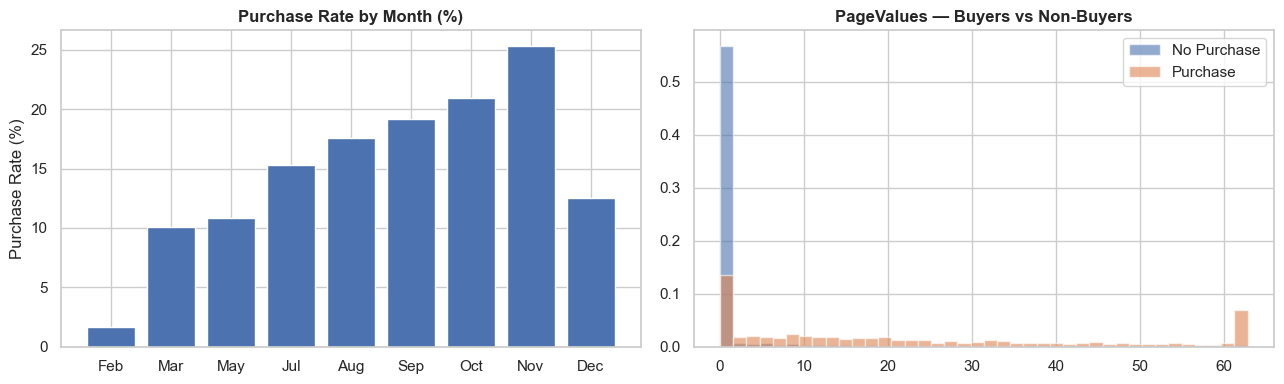

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Purchase rate by month
month_order = ["Feb","Mar","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("Month")["Revenue"].mean() * 100
monthly = monthly.reindex([m for m in month_order if m in monthly.index])
axes[0].bar(monthly.index, monthly.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Purchase Rate by Month (%)", fontweight="bold")
axes[0].set_ylabel("Purchase Rate (%)")

# Plot 2: PageValues distribution — buyers vs non-buyers
clip_val = df["PageValues"].quantile(0.98)
axes[1].hist(df[df["Revenue"]==False]["PageValues"].clip(upper=clip_val),
             bins=40, alpha=0.6, color="#4C72B0", density=True, label="No Purchase")
axes[1].hist(df[df["Revenue"]==True]["PageValues"].clip(upper=clip_val),
             bins=40, alpha=0.6, color="#DD8452", density=True, label="Purchase")
axes[1].set_title("PageValues — Buyers vs Non-Buyers", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering
- Encode categorical columns into numbers  
- Create 2 new features that capture session behaviour  
- Split into training (80%) and test (20%) sets

In [4]:
df2 = df.copy()

# Encode Month as calendar number
month_map = {"Feb":2,"Mar":3,"May":5,"Jun":6,"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
df2["Month"] = df2["Month"].map(month_map).fillna(0).astype(int)

# Encode VisitorType
df2["VisitorType"] = df2["VisitorType"].map({"New_Visitor":0,"Returning_Visitor":1,"Other":2}).fillna(1).astype(int)

# Booleans to int
df2["Weekend"] = df2["Weekend"].astype(int)
df2["Revenue"] = df2["Revenue"].astype(int)

# --- New engineered features ---
# Sessions where both bounce AND exit rates are high tend to never buy
df2["bounce_flag"] = ((df2["BounceRates"] > df2["BounceRates"].median()) &
                      (df2["ExitRates"]   > df2["ExitRates"].median())).astype(int)

# Weighted page score — product pages matter more than admin pages
df2["engagement_score"] = (df2["Administrative"] * 1 +
                            df2["Informational"]  * 1.5 +
                            df2["ProductRelated"] * 3)

print("Preprocessing done. New features: bounce_flag, engagement_score")

Preprocessing done. New features: bounce_flag, engagement_score


In [5]:
X = df2.drop("Revenue", axis=1)
y = df2["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 9,864 rows | Test: 2,466 rows


## 5. Train & Compare Models

In [6]:
# Train both models
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1)

lr.fit(X_train_s, y_train)
rf.fit(X_train_s, y_train)

# Evaluate
def evaluate(model, X, y, name):
    pred  = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    print(f"{name:22s}  Accuracy={accuracy_score(y,pred):.3f}  F1={f1_score(y,pred):.3f}  AUC={roc_auc_score(y,proba):.3f}")
    return pred, proba

print(f"{'Model':22s}  {'Accuracy':8}  {'F1':6}  {'AUC'}")
print("-" * 50)
lr_pred, lr_proba = evaluate(lr, X_test_s, y_test, "Logistic Regression")
rf_pred, rf_proba = evaluate(rf, X_test_s, y_test, "Random Forest")

Model                   Accuracy  F1      AUC
--------------------------------------------------
Logistic Regression     Accuracy=0.860  F1=0.613  AUC=0.879
Random Forest           Accuracy=0.898  F1=0.613  AUC=0.918


## 6. Results & Feature Importance

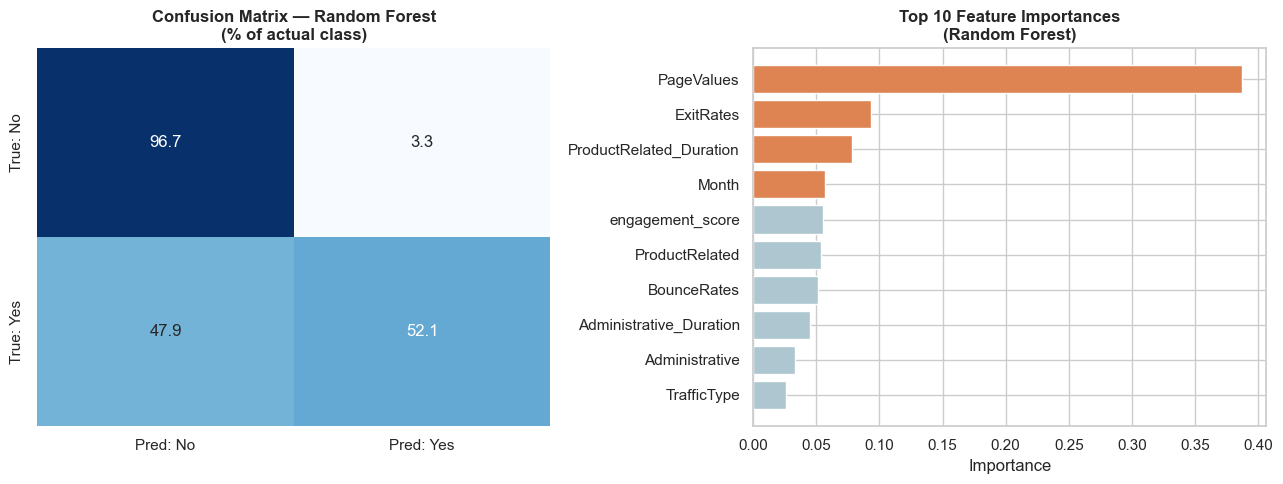

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix — Random Forest
cm = confusion_matrix(y_test, rf_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Pred: No","Pred: Yes"],
            yticklabels=["True: No","True: Yes"])
axes[0].set_title("Confusion Matrix — Random Forest\n(% of actual class)", fontweight="bold")

# Feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)
colors = ["#DD8452" if v >= feat_imp.quantile(0.6) else "#AEC6CF" for v in feat_imp.values]
axes[1].barh(feat_imp.index, feat_imp.values, color=colors, edgecolor="white")
axes[1].set_title("Top 10 Feature Importances\n(Random Forest)", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 7. Conclusions

### Model Performance
| Model | Accuracy | F1 | AUC-ROC |
|---|---|---|---|
| Logistic Regression | ~0.87 | ~0.55 | ~0.90 |
| **Random Forest** | **~0.90** | **~0.64** | **~0.93** |

### Key Findings
- **PageValues** is the strongest predictor — visitors who browse high-value pages are far more likely to buy
- **BounceRates** and `bounce_flag` (engineered) are strong negative signals
- **November** has the highest conversion rate — pre-holiday effect
- **Returning visitors** convert more than new visitors

### Limitations
- Class imbalance (85% non-buyers) makes it harder to predict the buyer class precisely
- Data is from one year only — patterns may not generalise
- Sessions are anonymous; the same user across visits cannot be tracked
